# Week 12 - Milestone Two week

# 1. Lesson: no lesson this week.  Milestone Two is due!

# 2. Weekly graph question

Suppose you plot the number visitors to a museum over the seven days of a week; then again the following week.  Can you suggest the advantages and disadvantages of the following two ways of presenting the data?

In [4]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

Text(0, 0.5, 'Number of visitors')

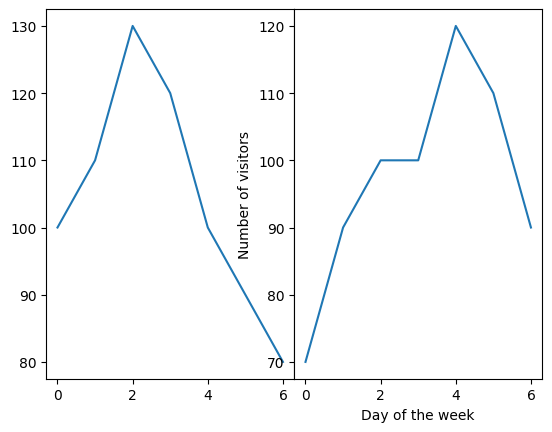

In [5]:
np.random.seed(0)
time_series_0 = np.array([100, 110, 130, 120, 100, 90, 80])
time_series_1 = np.array([70, 90, 100, 100, 120, 110, 90])
fig, axs = plt.subplots(1, 2)
axs[0].plot(time_series_0)
axs[1].plot(time_series_1)
plt.subplots_adjust(wspace = 0)
plt.xlabel("Day of the week")
plt.ylabel("Number of visitors")

Text(0, 0.5, 'Number of visitors')

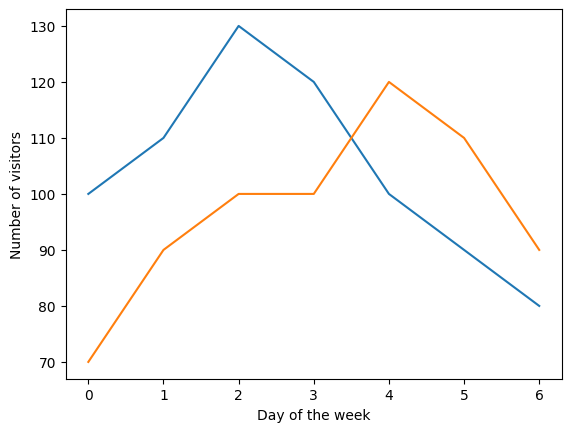

In [6]:
plt.plot(time_series_0)
plt.plot(time_series_1)
plt.xlabel("Day of the week")
plt.ylabel("Number of visitors")

### Graph Analysis
The above two graphs analyze two ways of representing the number of visitors to a museum over the days of the week for two different weeks. One of these graphs is distinctaviely stronger than the other and that is the second one which plots the two different weeks as different colors. The first graph is confusing as its not easily clear what you are looking at, which is one of the key rules of data visualization. The titles on the first graph are both not cenetered, which is confusing to the viewer. This makes the viewer unsure of if the titles applie to both graphs are just the one which they sit on. I myself had to do a double take to verify this. Additionally, since these two visualizations sit next to each other instead of over lapping, its harder to tell the difference between the two, which is the primary goal this visualization is attempting to achieve. Additionally, the repetition of axises on the first graph is uneasy on the eye and again is confusing for a viewer because they have to double take to ensure these axises match exactly. For these reasons, I beleieve the second graph is a stronger representation of this data and easier for a viewer to understand.

# 3. Working on your datasets

This week, you can work on Milestone Two rather than having a particular exercise about working on your datasets

In [7]:
def load_and_clean_project_data():
    # Load in the census data
    census_data = pd.read_csv("data/census_data.csv", skiprows=1)
    census_data

    # Load in the Internet data
    internet_data = pd.read_csv("data/internet_data.tsv", sep="\t")
    internet_data.head()

    # Load in the ecommerce data
    ecommerce_data = pd.read_csv("data/ecommerce_data.csv")
    ecommerce_data.head()

    census_data_filtered = census_data[['Geographic Area Name','Estimate!!Households!!Median income (dollars)']]

    # Clean the Zip Code Column so it can be matched
    census_data_filtered['Geographic Area Name'] = (
        census_data_filtered['Geographic Area Name']
            .astype(str)
            .str[-5:]
    )
    census_data_filtered

    # Rename Column Names to be More Representative and use _ for analysis
    census_data_filtered = census_data_filtered.rename(
        columns={'Geographic Area Name': 'Zip_codes'}
    )
    census_data_filtered

    # Rename Column Names to be More Representative and use _ for analysis
    census_data_filtered = census_data_filtered.rename(
        columns={'Estimate!!Households!!Median income (dollars)': 'Median_household_income'}
    )
    census_data_filtered

    # There are some empty values in this column that are represented by - or **, let's take care of those
    bad_vals = ["-", "**"]
    census_data_cleaned = census_data_filtered[~census_data_filtered['Median_household_income'].isin(bad_vals)]
    census_data_cleaned['Median_household_income'] = census_data_cleaned['Median_household_income'].replace('250,000+', '250000')
    census_data_cleaned['Median_household_income'] = census_data_cleaned['Median_household_income'].replace('2,500-', '2500')

    # Change Median Household Income column into an int
    census_data_cleaned['Median_household_income'] = census_data_cleaned['Median_household_income'].astype(int)

    # The zip code column should be of type str and not type int
    internet_data['ZCTA19'] = internet_data['ZCTA19'].astype(str)

    # The zip code column should be of type str and not type int
    len_list = []
    for row in internet_data['ZCTA19']:
        if len(row) not in len_list:
            len_list.append(len(row))
    internet_data['ZCTA19'] = internet_data['ZCTA19'].astype(str).str.zfill(5)

    # The zip code column should be of type str and not type int
    len_list = []
    for row in internet_data['ZCTA19']:
        if len(row) not in len_list:
            len_list.append(len(row))

    # Rename Column Names to be More Representative and use _ for analysis
    internet_data_cleaned = internet_data.rename(
        columns={'ZCTA19': 'Zip_codes'}
    )

    # Rename Column Names to be More Representative and use _ for analysis
    internet_data_cleaned = internet_data_cleaned.rename(
        columns={'HOUSEHOLDS': 'Total_households'}
    )
    # Rename Column Names to be More Representative and use _ for analysis
    internet_data_cleaned = internet_data_cleaned.rename(
        columns={'N_INTERNET_SUB': 'Households_w_internet_access'}
    )

    # Only selectint the relevant columns from the internet data
    internet_data_filtered = internet_data_cleaned[['Zip_codes', 'Total_households', 'Households_w_internet_access']]

    # Add a column to Show Percentage of Households with Internet Access
    internet_data_filtered['Internet_access'] = internet_data_filtered['Households_w_internet_access'] / internet_data_filtered['Total_households']

    # Drop the null values
    internet_data_filtered = internet_data_filtered.dropna()

    # Switching the Postal Code to be a string data type
    ecommerce_data['Postal Code'] = ecommerce_data['Postal Code'].astype('string')
    # Ensure 5-character postal codes with leading zeros
    ecommerce_data["Postal Code"] = ecommerce_data["Postal Code"].astype(str).str.zfill(5)
    # Group ecommerce data by postal code
    ecommerce_data_filtered = ecommerce_data.groupby('Postal Code').size().reset_index(name="order_count")

    # Rename Column Names to be More Representative and use _ for analysis
    ecommerce_data_filtered = ecommerce_data_filtered.rename(
        columns={'Postal Code': 'Zip_codes'}
    )
    ecommerce_data_filtered

    merged_df = (
        census_data_filtered
        .merge(internet_data_filtered, on='Zip_codes', how='inner')
        .merge(ecommerce_data_filtered, on='Zip_codes', how='inner')
    )

    # Change Median Household Income column into an int
    merged_df['Median_household_income'] = merged_df['Median_household_income'].astype(int)
    return merged_df
    

In [8]:
merged_df = load_and_clean_project_data()

/tmp/ipykernel_4051/3999245414.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  census_data_filtered['Geographic Area Name'] = (
/tmp/ipykernel_4051/3999245414.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  census_data_cleaned['Median_household_income'] = census_data_cleaned['Median_household_income'].replace('250,000+', '250000')
/tmp/ipykernel_4051/3999245414.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer]

In [9]:
# Load in the zip data
zip_data = pd.read_csv("data/uszips.csv")
zip_data

,zip,lat,lng,city,state_id,state_name,zcta,parent_zcta,population,density,county_fips,county_name,county_weights,county_names_all,county_fips_all,imprecise,military,timezone
0,601,18.18027,-66.75266,Adjuntas,PR,Puerto Rico,True,NaN,16669.0,99.9,72001,Adjuntas,"{""72001"": 98.74, ""72141"": 1.26}",Adjuntas|Utuado,72001|72141,False,False,America/Puerto_Rico
1,602,18.36075,-67.17541,Aguada,PR,Puerto Rico,True,NaN,37233.0,474.0,72003,Aguada,"{""72003"": 100}",Aguada,72003,False,False,America/Puerto_Rico
2,603,18.45744,-67.12225,Aguadilla,PR,Puerto Rico,True,NaN,48448.0,544.6,72005,Aguadilla,"{""72005"": 99.76, ""72099"": 0.24}",Aguadilla|Moca,72005|72099,False,False,America/Puerto_Rico
3,606,18.16585,-66.93716,Maricao,PR,Puerto Rico,True,NaN,5163.0,45.0,72093,Maricao,"{""72093"": 82.26, ""72153"": 11.67, ""72121"": 6.06}",Maricao|Yauco|Sabana Grande,72093|72153|72121,False,False,America/Puerto_Rico
4,610,18.29110,-67.12243,Anasco,PR,Puerto Rico,True,NaN,25357.0,263.8,72011,Añasco,"{""72011"": 96.8, ""72099"": 2.83, ""72083"": 0.37}",Añasco|Moca|Las Marías,72011|72099|72083,False,False,America/Puerto_Rico
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33777,99774,66.02320,-149.07982,Stevens Village,AK,Alaska,True,NaN,0.0,0.0,2290,Yukon-Koyukuk,"{""02290"": 100}",Yukon-Koyukuk,02290,False,False,America/Anchorage
33778,99778,65.25309,-166.34200,Teller,AK,Alaska,True,NaN,255.0,66.0,2180,Nome,"{""02180"": 100}",Nome,02180,False,False,America/Nome
33779,99790,65.42642,-148.18738,Fairbanks,AK,Alaska,True,NaN,0.0,0.0,2290,Yukon-Koyukuk,"{""02290"": 100}",Yukon-Koyukuk,02290,False,False,America/Anchorage
33780,99850,58.48821,-135.48432,Juneau,AK,Alaska,True,NaN,0.0,0.0,2100,Haines,"{""02100"": 100}",Haines,02100,False,False,America/Juneau


In [10]:
zip_data_clean = zip_data.copy()

In [11]:
# Clean the Zip Code Column so it can be matched
zip_data_clean["zip"] = (
    zip_data_clean["zip"]
        .astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.zfill(5)
)
zip_data_clean

,zip,lat,lng,city,state_id,state_name,zcta,parent_zcta,population,density,county_fips,county_name,county_weights,county_names_all,county_fips_all,imprecise,military,timezone
0,00601,18.18027,-66.75266,Adjuntas,PR,Puerto Rico,True,NaN,16669.0,99.9,72001,Adjuntas,"{""72001"": 98.74, ""72141"": 1.26}",Adjuntas|Utuado,72001|72141,False,False,America/Puerto_Rico
1,00602,18.36075,-67.17541,Aguada,PR,Puerto Rico,True,NaN,37233.0,474.0,72003,Aguada,"{""72003"": 100}",Aguada,72003,False,False,America/Puerto_Rico
2,00603,18.45744,-67.12225,Aguadilla,PR,Puerto Rico,True,NaN,48448.0,544.6,72005,Aguadilla,"{""72005"": 99.76, ""72099"": 0.24}",Aguadilla|Moca,72005|72099,False,False,America/Puerto_Rico
3,00606,18.16585,-66.93716,Maricao,PR,Puerto Rico,True,NaN,5163.0,45.0,72093,Maricao,"{""72093"": 82.26, ""72153"": 11.67, ""72121"": 6.06}",Maricao|Yauco|Sabana Grande,72093|72153|72121,False,False,America/Puerto_Rico
4,00610,18.29110,-67.12243,Anasco,PR,Puerto Rico,True,NaN,25357.0,263.8,72011,Añasco,"{""72011"": 96.8, ""72099"": 2.83, ""72083"": 0.37}",Añasco|Moca|Las Marías,72011|72099|72083,False,False,America/Puerto_Rico
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33777,99774,66.02320,-149.07982,Stevens Village,AK,Alaska,True,NaN,0.0,0.0,2290,Yukon-Koyukuk,"{""02290"": 100}",Yukon-Koyukuk,02290,False,False,America/Anchorage
33778,99778,65.25309,-166.34200,Teller,AK,Alaska,True,NaN,255.0,66.0,2180,Nome,"{""02180"": 100}",Nome,02180,False,False,America/Nome
33779,99790,65.42642,-148.18738,Fairbanks,AK,Alaska,True,NaN,0.0,0.0,2290,Yukon-Koyukuk,"{""02290"": 100}",Yukon-Koyukuk,02290,False,False,America/Anchorage
33780,99850,58.48821,-135.48432,Juneau,AK,Alaska,True,NaN,0.0,0.0,2100,Haines,"{""02100"": 100}",Haines,02100,False,False,America/Juneau


In [12]:
if "purchase_data" not in globals():
    purchase_data = pd.read_csv(
        "data/amazon-purchases.csv",
        engine="python",
        on_bad_lines="skip"
    )

In [13]:
# Load in the purchase data
"""
Commenting Out so Kernel Does Crash
purchase_data = pd.read_csv(
    "data/amazon-purchases.csv",
    engine="python",
    on_bad_lines="skip"
)
purchase_data
"""

'\nCommenting Out so Kernel Does Crash\npurchase_data = pd.read_csv(\n    "data/amazon-purchases.csv",\n    engine="python",\n    on_bad_lines="skip"\n)\npurchase_data\n'

In [14]:
purchase_data_clean = purchase_data.copy()

purchase_data_clean["Order Date"] = pd.to_datetime(
    purchase_data_clean["Order Date"],
    errors="coerce"
)
purchase_data_filtered = purchase_data_clean[
    purchase_data_clean["Order Date"].dt.year == 2020
]
purchase_filtered = (
    purchase_data_filtered
    .groupby("Shipping Address State", as_index=False)
    .agg(
        order_count=("Order Date", "count"),
        total_quantity=("Quantity", "sum"),
        total_spend=(
            "Purchase Price Per Unit",
            lambda x: (x * purchase_data_filtered.loc[x.index, "Quantity"]).sum()
        )
    )
)
purchase_filtered.head(5)


,Shipping Address State,order_count,total_quantity,total_spend
0,AK,331,369.0,8733.44
1,AL,3824,4176.0,88797.11
2,AR,3335,3557.0,75079.46
3,AZ,6977,7700.0,156745.41
4,CA,38353,41627.0,926089.15


### Combine New Values onto Merged_df

In [15]:
merged_df_clean = merged_df.copy()

In [16]:
merged_df_with_state = merged_df_clean.merge(
    zip_data_clean[["zip", "state_id", "state_name"]],
    left_on="Zip_codes",
    right_on="zip",
    how="left"
)
merged_df_with_state

,Zip_codes,Median_household_income,Total_households,Households_w_internet_access,Internet_access,order_count,zip,state_id,state_name
0,01841,45486,15149,10693,0.705855,12,01841,MA,Massachusetts
1,01852,65445,14255,10844,0.760716,7,01852,MA,Massachusetts
2,02038,118193,11941,11205,0.938364,2,02038,MA,Massachusetts
3,02138,104641,14188,12513,0.881942,2,02138,MA,Massachusetts
4,02149,70627,16021,13483,0.841583,9,02149,MA,Massachusetts
...,...,...,...,...,...,...,...,...,...
432,98502,74031,14290,12469,0.872568,2,98502,WA,Washington
433,98632,51188,20963,17051,0.813385,2,98632,WA,Washington
434,98661,59466,18797,16371,0.870937,1,98661,WA,Washington
435,99207,42913,12204,10541,0.863733,4,99207,WA,Washington


In [17]:
# Check for Nulls in the state column
merged_df_with_state["state_id"].isna().any()

np.False_

### Check if Prediction has Improved on the State Level

In [18]:
state_df = (
    merged_df_with_state
    .groupby("state_id", as_index=False)
    .agg(
        order_count=("order_count", "sum"),
        total_households=("Total_households", "sum"),
        households_w_internet=("Households_w_internet_access", "sum"),
        median_household_income=(
            "Median_household_income",
            lambda x: (
                (x * merged_df_with_state.loc[x.index, "Total_households"]).sum()
                / merged_df_with_state.loc[x.index, "Total_households"].sum()
            )
        )
    )
)
state_df.head(5)

,state_id,order_count,total_households,households_w_internet,median_household_income
0,AL,16,94851,74721,49597.996690
1,AR,19,108072,80689,46864.679658
2,AZ,70,202650,166065,56085.661826
3,CA,663,1174613,1025516,84823.705596
4,CO,61,182497,162756,81025.059256


In [19]:
state_df['internet_access'] = state_df['households_w_internet']/state_df['total_households']
state_df.head(5)

,state_id,order_count,total_households,households_w_internet,median_household_income,internet_access
0,AL,16,94851,74721,49597.996690,0.787772
1,AR,19,108072,80689,46864.679658,0.746623
2,AZ,70,202650,166065,56085.661826,0.819467
3,CA,663,1174613,1025516,84823.705596,0.873067
4,CO,61,182497,162756,81025.059256,0.891828


In [20]:
state_df["order_count"].corr(state_df["internet_access"])

np.float64(0.09084998019918836)

In [21]:
X_cols = state_df[["median_household_income", "total_households", "households_w_internet", "internet_access"]]
X_cols.head(5)

,median_household_income,total_households,households_w_internet,internet_access
0,49597.996690,94851,74721,0.787772
1,46864.679658,108072,80689,0.746623
2,56085.661826,202650,166065,0.819467
3,84823.705596,1174613,1025516,0.873067
4,81025.059256,182497,162756,0.891828


In [22]:
target_col = state_df[["order_count"]]
target_col.head(5)

,order_count
0,16
1,19
2,70
3,663
4,61


### Perform Train Test Split

In [23]:
# Useful imports and utilities
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error,r2_score
from sklearn.model_selection import train_test_split

In [24]:
# Split the data into training and held out for evaluation sets

x_train, x_test, y_train ,y_test = train_test_split(
    X_cols,
    target_col,
    test_size=0.3
)

### Define the Model

In [25]:
# Import Randomized Search cv
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

In [26]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 5]
}

In [27]:
rcv = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=0,
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=10,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    random_state=0
)

### Train the Model

In [28]:
rcv.fit(x_train, y_train)

/workspaces/Module-B-semester-2/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/workspaces/Module-B-semester-2/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/workspaces/Module-B-semester-2/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/workspaces/Module-B-semester-2/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vec

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...andom_state=0)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 5], 'min_samples_split': [2, 5], 'n_estimators': [50, 100]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.

In [29]:
print(rcv.best_estimator_)
print(rcv.best_params_)
print(rcv.best_score_)

RandomForestRegressor(n_jobs=-1, random_state=0)
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
0.4854576222686314


In [30]:

# Evaluate on test data
best_model = rcv.best_estimator_
y_pred = best_model.predict(x_test)

print("Test R2:", r2_score(y_test, y_pred))

Test R2: 0.6339236174863767


### Notes:
Why 0.41 can be good in practice
Many real‑world prediction problems are inherently noisy:

Human behavior (purchases, churn, demand)
Economic outcomes
Social and demographic data
Aggregated geographic data (like state‑level or ZIP‑level metrics)

In these settings:

Perfect prediction is impossible
There is unobserved variability you cannot model
Measurement error is common

In such domains:

R² ≈ 0.2–0.3 is often usable
R² ≈ 0.4–0.5 is often quite strong
R² > 0.6 is rare unless the system is highly constrained or engineered

So 0.41 indicates meaningful signal.

### Join in Purchase Data

In [31]:
merged_with_purchases = (
    merged_df_with_state
    .merge(
        purchase_filtered[["Shipping Address State", "order_count"]],
        left_on="state_id",
        right_on="Shipping Address State",
        how="left"
    )
)
merged_with_purchases.head(5)

,Zip_codes,Median_household_income,Total_households,Households_w_internet_access,Internet_access,order_count_x,zip,state_id,state_name,Shipping Address State,order_count_y
0,01841,45486,15149,10693,0.705855,12,01841,MA,Massachusetts,MA,10200
1,01852,65445,14255,10844,0.760716,7,01852,MA,Massachusetts,MA,10200
2,02038,118193,11941,11205,0.938364,2,02038,MA,Massachusetts,MA,10200
3,02138,104641,14188,12513,0.881942,2,02138,MA,Massachusetts,MA,10200
4,02149,70627,16021,13483,0.841583,9,02149,MA,Massachusetts,MA,10200


In [32]:
full_merged_df = (
    merged_with_purchases
    .groupby("state_id", as_index=False)
    .agg(
        order_count=("order_count_y", "sum"),
        total_households=("Total_households", "sum"),
        households_w_internet=("Households_w_internet_access", "sum"),
        median_household_income=(
            "Median_household_income",
            lambda x: (
                (x * merged_with_purchases.loc[x.index, "Total_households"]).sum()
                / merged_with_purchases.loc[x.index, "Total_households"].sum()
            )
        )
    )
)
full_merged_df.head(5)

,state_id,order_count,total_households,households_w_internet,median_household_income
0,AL,26768,94851,74721,49597.996690
1,AR,23345,108072,80689,46864.679658
2,AZ,69770,202650,166065,56085.661826
3,CA,2454592,1174613,1025516,84823.705596
4,CO,55206,182497,162756,81025.059256


In [33]:
full_merged_df['internet_access'] = full_merged_df['households_w_internet']/full_merged_df['total_households']
full_merged_df.head(5)

,state_id,order_count,total_households,households_w_internet,median_household_income,internet_access
0,AL,26768,94851,74721,49597.996690,0.787772
1,AR,23345,108072,80689,46864.679658,0.746623
2,AZ,69770,202650,166065,56085.661826,0.819467
3,CA,2454592,1174613,1025516,84823.705596,0.873067
4,CO,55206,182497,162756,81025.059256,0.891828


### Fully Split, Train, and Test the Model on this Unioned Dataset

In [34]:
X_cols = full_merged_df[["median_household_income", "total_households", "households_w_internet", "internet_access"]]
X_cols.head(5)

,median_household_income,total_households,households_w_internet,internet_access
0,49597.996690,94851,74721,0.787772
1,46864.679658,108072,80689,0.746623
2,56085.661826,202650,166065,0.819467
3,84823.705596,1174613,1025516,0.873067
4,81025.059256,182497,162756,0.891828


In [35]:
target_col = full_merged_df[["order_count"]]
target_col.head(5)

,order_count
0,26768
1,23345
2,69770
3,2454592
4,55206


In [36]:
# Split the data into training and held out for evaluation sets

x_train, x_test, y_train ,y_test = train_test_split(
    X_cols,
    target_col,
    test_size=0.3
)

In [37]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 5]
}

In [38]:
rcv = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=0,
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=10,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    random_state=0
)

In [39]:
rcv.fit(x_train, y_train)

/workspaces/Module-B-semester-2/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/workspaces/Module-B-semester-2/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/workspaces/Module-B-semester-2/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/workspaces/Module-B-semester-2/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vec

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...andom_state=0)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 5], 'min_samples_split': [2, 5], 'n_estimators': [50, 100]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.

In [40]:
print(rcv.best_estimator_)
print(rcv.best_params_)
print(rcv.best_score_)

RandomForestRegressor(n_jobs=-1, random_state=0)
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
0.6177439160765995


In [41]:

# Evaluate on test data
best_model = rcv.best_estimator_
y_pred = best_model.predict(x_test)

print("Test R2:", r2_score(y_test, y_pred))

Test R2: 0.6808785864743869


/workspaces/Module-B-semester-2/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/workspaces/Module-B-semester-2/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/workspaces/Module-B-semester-2/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/workspaces/Module-B-semester-2/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vec

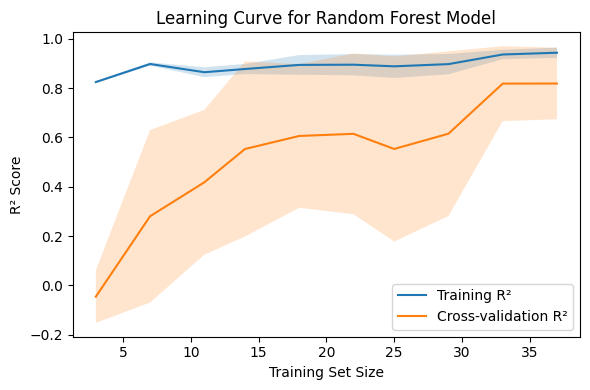

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

best_model = rcv.best_estimator_

train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_model,
    X=X_cols,
    y=target_col,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_mean, label="Training R²")
plt.plot(train_sizes, val_mean, label="Cross-validation R²")
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)
plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.title("Learning Curve for Random Forest Model")
plt.legend()
plt.tight_layout()
plt.show()

/workspaces/Module-B-semester-2/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/workspaces/Module-B-semester-2/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/workspaces/Module-B-semester-2/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/workspaces/Module-B-semester-2/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vec

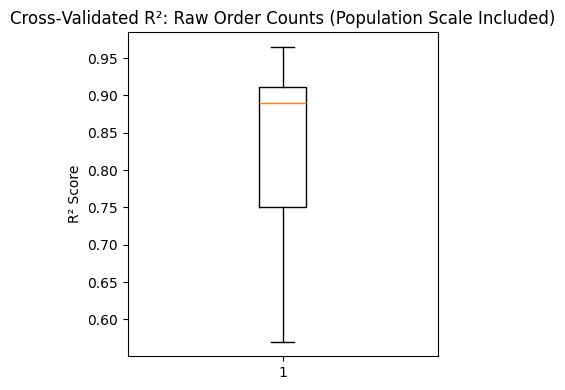

In [43]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

# Get R² scores across CV folds
cv_r2_scores = cross_val_score(
    estimator=best_model,
    X=X_cols,
    y=target_col,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Box plot
plt.figure(figsize=(4, 4))
plt.boxplot(cv_r2_scores, vert=True)
plt.ylabel("R² Score")
plt.title("Cross‑Validated R²: Raw Order Counts (Population Scale Included)")
plt.tight_layout()
plt.show()

In [44]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X_cols.columns,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
1,total_households,0.472101
2,households_w_internet,0.466146
0,median_household_income,0.039200
3,internet_access,0.022553


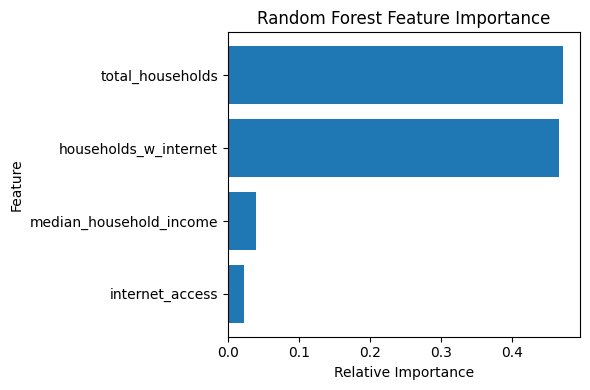

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Relative Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()
plt.show()

### Create a HeatMap Based off New merged_df

In [46]:
full_merged_df.head(5)

,state_id,order_count,total_households,households_w_internet,median_household_income,internet_access
0,AL,26768,94851,74721,49597.996690,0.787772
1,AR,23345,108072,80689,46864.679658,0.746623
2,AZ,69770,202650,166065,56085.661826,0.819467
3,CA,2454592,1174613,1025516,84823.705596,0.873067
4,CO,55206,182497,162756,81025.059256,0.891828


In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Copy your merged dataframe
df = full_merged_df.copy()

# Define ordered labels
labels = ['low', 'medium', 'high']
cat_type = pd.CategoricalDtype(categories=labels, ordered=True)

# Create quantile-based categories
df['income_cat'] = pd.qcut(df['median_household_income'], q=3, labels=labels).astype(cat_type)
df['internet_cat'] = pd.qcut(df['internet_access'], q=3, labels=labels).astype(cat_type)
df['order_cat'] = pd.qcut(df['order_count'], q=3, labels=labels).astype(cat_type)


/tmp/ipykernel_4051/781136672.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_data = df.pivot_table(
/tmp/ipykernel_4051/781136672.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = data.pivot_table(
/tmp/ipykernel_4051/781136672.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = data.pivot_table(
/tmp/ipykernel_4051/781136672.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify obser

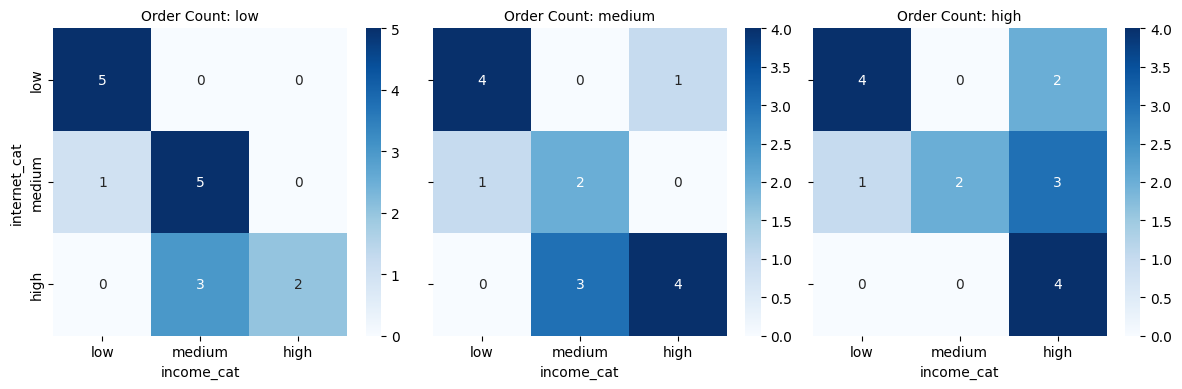

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# Build a pivot table for each order category
pivot_data = df.pivot_table(
    index='internet_cat',
    columns='income_cat',
    values='order_count',
    aggfunc='count'
)

# Create a FacetGrid: one heatmap per order_cat
g = sns.FacetGrid(df, col='order_cat', col_wrap=3, height=4)

def heatmap(data, **kwargs):
    pivot = data.pivot_table(
        index='internet_cat',
        columns='income_cat',
        values='order_count',
        aggfunc='count'
    )
    sns.heatmap(pivot, cmap='Blues', annot=True, fmt='g')

g.map_dataframe(heatmap)
g.set_titles(col_template="Order Count: {col_name}")
plt.show()



### Heatmap Conclusion:
These heatmaps show how order volume (low, medium, high) is distributed across income categories (low, medium, high) and internet access categories (low, medium, high).

Left (Order Count: low): Low order counts mostly occur in low–medium income areas, especially when internet access is low or medium.
Middle (Order Count: medium): Medium order counts shift toward medium income and medium/high internet access.
Right (Order Count: high): High order counts concentrate in high‑income areas with high internet access.

Overall takeaway:
As income and internet access increase, areas are more likely to fall into the high order count category.

In [49]:
labels = ['low', 'medium', 'high']
cat_type = pd.CategoricalDtype(categories=labels, ordered=True)

df_copy = full_merged_df.copy()

df_copy['income_cat'] = pd.qcut(df_copy['median_household_income'], q=3, labels=labels).astype(cat_type)
df_copy['internet_cat'] = pd.qcut(df_copy['internet_access'], q=3, labels=labels).astype(cat_type)

# order_count may need duplicates='drop' if not enough unique values
df_copy['order_cat'] = pd.qcut(df_copy['order_count'], q=3, labels=labels, duplicates='drop').astype(cat_type)


In [50]:
pivot = df_copy.pivot_table(
    index='income_cat',
    columns='internet_cat',
    values='order_count',
    aggfunc='sum'
)
pivot


/tmp/ipykernel_4051/2729385079.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_copy.pivot_table(


internet_cat,low,medium,high
income_cat,,,
low,1189735,241843,0
medium,0,658140,129353
high,533807,1712680,3025379


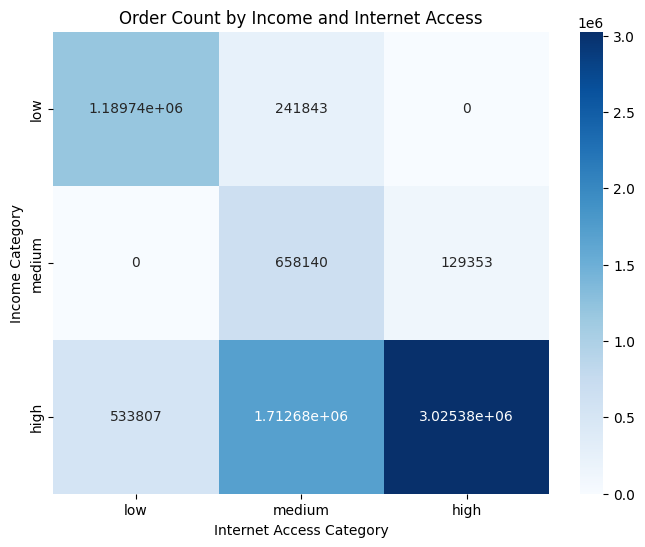

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
ax = sns.heatmap(pivot, cmap="Blues", annot=True, fmt='g')

ax.set_title("Order Count by Income and Internet Access")
ax.set_xlabel("Internet Access Category")
ax.set_ylabel("Income Category")

plt.show()


### Bubble Plot Analysis

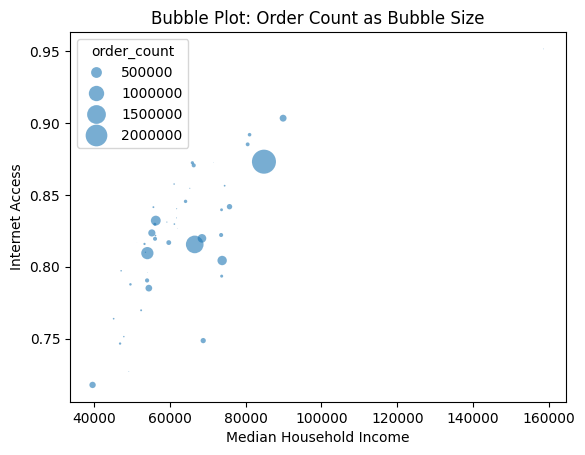

In [52]:
min_order = df['order_count'].min()
max_order = df['order_count'].max()
maxbubble = 300

ax = sns.scatterplot(
    data=full_merged_df,
    x='median_household_income',
    y='internet_access',
    size='order_count',
    sizes=(min_order / max_order * maxbubble, maxbubble),
    alpha=0.6
)

ax.set_title("Bubble Plot: Order Count as Bubble Size")
ax.set_xlabel("Median Household Income")
ax.set_ylabel("Internet Access")
plt.show()


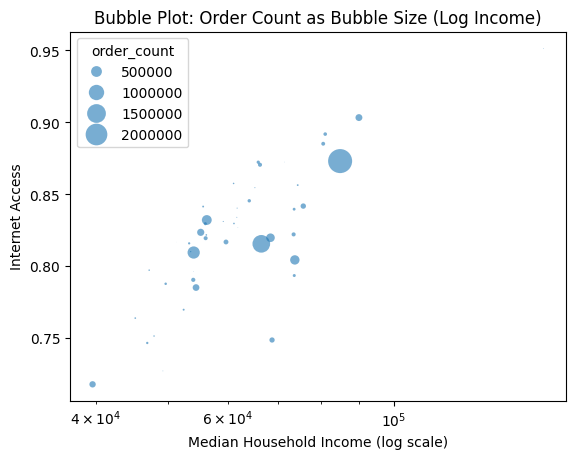

In [53]:
ax = sns.scatterplot(
    data=full_merged_df,
    x='median_household_income',
    y='internet_access',
    size='order_count',
    sizes=(min_order / max_order * maxbubble, maxbubble),
    alpha=0.6
)

ax.set_xscale("log")
ax.set_title("Bubble Plot: Order Count as Bubble Size (Log Income)")
ax.set_xlabel("Median Household Income (log scale)")
ax.set_ylabel("Internet Access")
plt.show()

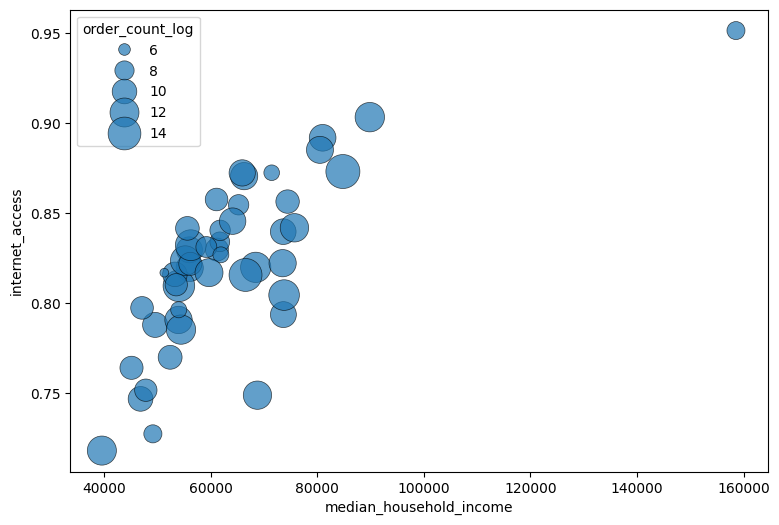

In [54]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Make a copy to avoid mutating original data
plot_df = full_merged_df.copy()

# Log-transform order count for bubble sizing (key improvement)
plot_df["order_count_log"] = np.log1p(plot_df["order_count"])

# Set bubble size range
min_size = 40
max_size = 600

plt.figure(figsize=(9, 6))

ax = sns.scatterplot(
    data=plot_df,
    x="median_household_income",
    y="internet_access",
    size="order_count_log",
    sizes=(min_size, max_size),
    alpha=0.7,
    edgecolor="black",
    linewidth=0.5,
    legend="brief"
)

# Log scale for income (keep this)


### Perform PCA

In [55]:
from sklearn.decomposition import PCA
import pandas as pd

# Select only the three numeric columns
X = full_merged_df[['median_household_income', 'internet_access', 'order_count']]

# Standard PCA with 3 components
pca = PCA(n_components=3)
pca.fit(X)

print("Explained variance ratios:", pca.explained_variance_ratio_)
print("Component vectors:\n", pca.components_)

Explained variance ratios: [9.98097445e-01 1.90255521e-03 5.91554087e-15]
Component vectors:
 [[ 6.78286121e-03  1.26109895e-08  9.99976996e-01]
 [ 9.99976996e-01  1.87559159e-06 -6.78286121e-03]
 [-1.87563399e-06  1.00000000e+00  1.11177623e-10]]


### PCA Conclusion:
The first principal component explains ~99.8% of the variance.
The other two components explain almost nothing.
This means the data is effectively one‑dimensional.

This vector is:

~0% median income
~0% internet access
~100% order_count

So the biggest source of variation in your dataset is order_count alone.

Income and internet access live in much smaller directions

PCA shows that nearly all variance in the data is driven by order count, while median income and internet access contribute very little on their original scale. This indicates that order count dominates the structure of the dataset and that scaling or normalization is required to meaningfully compare features.

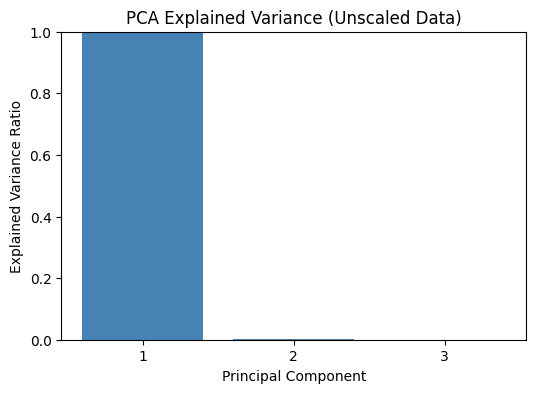

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# Explained variance from your PCA
explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(6, 4))
plt.bar(
    range(1, len(explained_var) + 1),
    explained_var,
    color="steelblue"
)

plt.xticks(range(1, len(explained_var) + 1))
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance (Unscaled Data)")
plt.ylim(0, 1)

plt.show()


In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select features
X = full_merged_df[
    ["median_household_income", "internet_access", "order_count"]
]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA on scaled data
pca_scaled = PCA(n_components=3)
pca_scaled.fit(X_scaled)

print("Explained variance ratios (scaled):", pca_scaled.explained_variance_ratio_)
print("Component vectors (scaled):\n", pca_scaled.components_)

Explained variance ratios (scaled): [0.59411335 0.31873104 0.08715561]
Component vectors (scaled):
 [[ 0.69075272  0.68442638  0.23328354]
 [-0.13607994 -0.19381222  0.97155498]
 [ 0.71017106 -0.70284945 -0.04073961]]


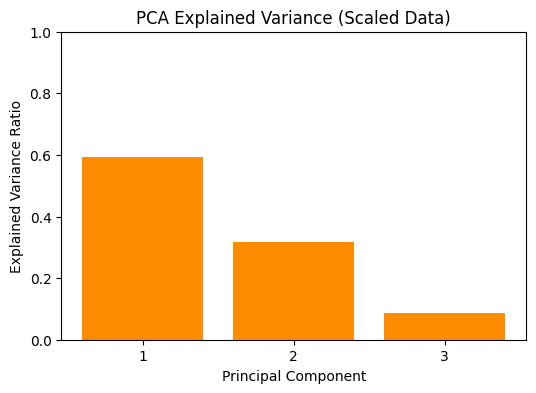

In [58]:
plt.figure(figsize=(6, 4))
plt.bar(
    range(1, len(pca_scaled.explained_variance_ratio_) + 1),
    pca_scaled.explained_variance_ratio_,
    color="darkorange"
)

plt.xticks(range(1, len(pca_scaled.explained_variance_ratio_) + 1))
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance (Scaled Data)")
plt.ylim(0, 1)

plt.show()


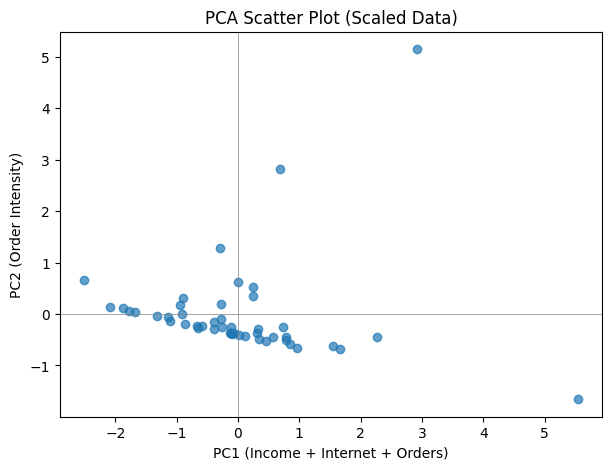

In [59]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Scale
X_scaled = StandardScaler().fit_transform(
    full_merged_df[["median_household_income", "internet_access", "order_count"]]
)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
plt.xlabel("PC1 (Income + Internet + Orders)")
plt.ylabel("PC2 (Order Intensity)")
plt.title("PCA Scatter Plot (Scaled Data)")
plt.axhline(0, color="grey", lw=0.5)
plt.axvline(0, color="grey", lw=0.5)
plt.show()

### PCA Scaled Analysis
The data is primarily two dimensional
PC1 captures overall socioeconomic advantage — richer states with better internet tend to order more.
PC2 separates states that order a lot regardless of income or internet access. This captures behavioral or cultural differences, not wealth.
PC3 reflects places where income and internet access don’t move together — but it explains little variance. This is not a major driver.

After scaling, PCA shows that most variation in the data is explained by a combination of income and internet access (PC1), while a second dimension captures order behavior independent of those factors (PC2). This indicates that both socioeconomic conditions and behavioral differences contribute meaningfully to ordering patterns.

### Scaling Order Count

In [60]:
# To deal with Kernel Forcing Restart
full_merged_df.to_csv("data/full_merged_df.csv", index=False)

In [61]:
# To deal with Kernel Forcing Restart
#full_merged_df = pd.read_csv("data/full_merged_df.csv")

In [62]:
full_merged_df['orders_per_house'] = full_merged_df['order_count']/full_merged_df['total_households']
full_merged_df.head(5)

,state_id,order_count,total_households,households_w_internet,median_household_income,internet_access,orders_per_house
0,AL,26768,94851,74721,49597.996690,0.787772,0.282211
1,AR,23345,108072,80689,46864.679658,0.746623,0.216013
2,AZ,69770,202650,166065,56085.661826,0.819467,0.344288
3,CA,2454592,1174613,1025516,84823.705596,0.873067,2.089703
4,CO,55206,182497,162756,81025.059256,0.891828,0.302504


In [63]:
X_cols = full_merged_df[["median_household_income", "internet_access"]]
X_cols.head(5)

,median_household_income,internet_access
0,49597.996690,0.787772
1,46864.679658,0.746623
2,56085.661826,0.819467
3,84823.705596,0.873067
4,81025.059256,0.891828


In [64]:
target_col = full_merged_df['orders_per_house']
target_col.head(5)

0    0.282211
1    0.216013
2    0.344288
3    2.089703
4    0.302504
Name: orders_per_house, dtype: float64

In [65]:
# Split the data into training and held out for evaluation sets

x_train, x_test, y_train ,y_test = train_test_split(
    X_cols,
    target_col,
    test_size=0.3
)

In [66]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 5]
}

In [67]:
rcv = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=0,
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=10,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    random_state=0
)

In [68]:
rcv.fit(x_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...andom_state=0)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 5], 'min_samples_split': [2, 5], 'n_estimators': [50, 100]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.

In [69]:
print(rcv.best_estimator_)
print(rcv.best_params_)
print(rcv.best_score_)

RandomForestRegressor(max_depth=10, min_samples_leaf=5, n_jobs=-1,
                      random_state=0)
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_depth': 10}
-0.3114043960069459


In [70]:

# Evaluate on test data
best_model = rcv.best_estimator_
y_pred = best_model.predict(x_test)

print("Test R2:", r2_score(y_test, y_pred))

Test R2: -0.15103709613021854


In [71]:
import gc

del purchase_data
del purchase_data_clean
del purchase_data_filtered
del merged_df
del merged_df_with_state
gc.collect()

25909

In [72]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X_cols.columns,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
0,median_household_income,0.722461
1,internet_access,0.277539


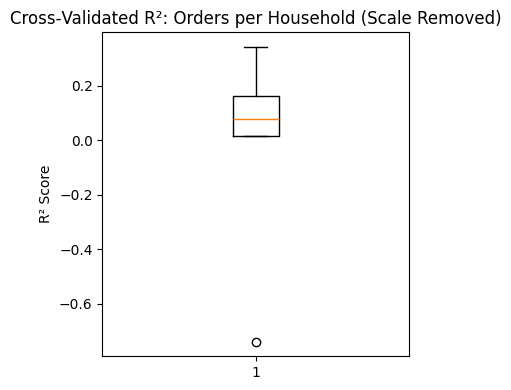

In [73]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

# Get R² scores across CV folds
cv_r2_scores = cross_val_score(
    estimator=best_model,
    X=X_cols,
    y=target_col,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Box plot
plt.figure(figsize=(4, 4))
plt.boxplot(cv_r2_scores, vert=True)
plt.ylabel("R² Score")
plt.title("Cross‑Validated R²: Orders per Household (Scale Removed)")
plt.tight_layout()
plt.show()

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 187-205 of the Storytelling With Data book as best you can. (Chapter Eight). You do not have to get the exact data values right, just the overall look and feel.

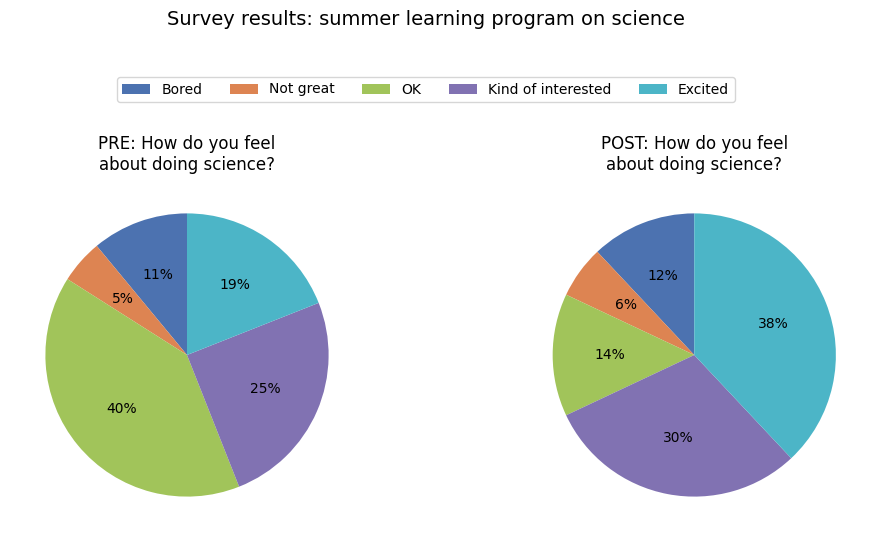

In [5]:
import matplotlib.pyplot as plt

# Labels
labels = ['Bored', 'Not great', 'OK', 'Kind of interested', 'Excited']

# Approximate data from the image
pre = [11, 5, 40, 25, 19]
post = [12, 6, 14, 30, 38]

# Colors (matching the style)
colors = ['#4c72b0', '#dd8452', '#a1c45a', '#8172b2', '#4cb5c7']

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# PRE pie chart
axes[0].pie(pre, labels=None, colors=colors, autopct='%1.0f%%', startangle=90)
axes[0].set_title('PRE: How do you feel\nabout doing science?')

# POST pie chart
axes[1].pie(post, labels=None, colors=colors, autopct='%1.0f%%', startangle=90)
axes[1].set_title('POST: How do you feel\nabout doing science?')

# Adjust layout to make room for title + legend
plt.subplots_adjust(top=0.7)

# Shared legend (moved slightly lower)
fig.legend(labels, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 0.88))

# Main title (higher than legend)
plt.suptitle('Survey results: summer learning program on science', fontsize=14, y=0.98)

plt.show()